# EXPLORE — интерактивная проверка датасета MBank ATM

Запусти все ячейки (Run All). Ноутбук **сам находит все файлы** датасета, проверяет
целостность, строит графики распределений и проверяет теории (реальная погода/курс,
зарплатные пики, аномалии). Каждая секция печатает вердикт ✅ / ⚠️.

> Запускать из папки `dataset/` (или из корня проекта — путь определится сам).


In [26]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pyarrow.parquet as pq, pyarrow.dataset as pads
from pathlib import Path
from collections import Counter
plt.rcParams['figure.figsize'] = (11, 3.3); pd.set_option('display.width', 150)

# --- найти папку датасета ---
P = Path.cwd()
DS = P if (P/'dimensions').exists() else (P/'dataset' if (P/'dataset').exists() else P/'atm_project'/'dataset')
DIM, FCT, LAB, EXT = DS/'dimensions', DS/'facts', DS/'labels', DS/'external'
print('dataset root:', DS)
assert DIM.exists(), 'не нашёл dimensions/ — запусти из папки dataset/'
verdicts = {}   # накопитель итоговых вердиктов


dataset root: /home/arsen/ML_classic_course/atm_project/dataset


## 1. Инвентарь — все файлы датасета
Что физически лежит: строки, колонки, размер.

In [27]:
def parquet_files(root):
    return sorted(root.rglob('*.parquet'))

rows = []
for grp, root in [('dimensions',DIM),('facts',FCT),('labels',LAB),('external',EXT)]:
    if grp == 'facts':
        ft = FCT/'fact_transactions'
        parts = list(ft.rglob('*.parquet'))
        if parts:
            n = sum(pq.read_metadata(p).num_rows for p in parts)
            sz = sum(p.stat().st_size for p in parts)/1e6
            rows.append(('facts','fact_transactions', n, pq.read_schema(parts[0]).names.__len__(), f'{sz:,.0f} MB / {len(parts)} парт.'))
        for f in FCT.glob('*.parquet'):
            m=pq.read_metadata(f); rows.append(('facts',f.stem,m.num_rows,len(pq.read_schema(f).names),f'{f.stat().st_size/1e3:,.0f} KB'))
    else:
        for f in parquet_files(root):
            m=pq.read_metadata(f); rows.append((grp,f.stem,m.num_rows,len(pq.read_schema(f).names),f'{f.stat().st_size/1e3:,.0f} KB'))
inv = pd.DataFrame(rows, columns=['group','table','rows','cols','size'])
print(inv.to_string(index=False))
print(f"\nВсего таблиц: {len(inv)}  |  строк в факте: {inv.loc[inv.table=='fact_transactions','rows'].iloc[0]:,}")
verdicts['1. инвентарь'] = f'✅ {len(inv)} таблиц читаются'


     group             table     rows  cols              size
dimensions           dim_atm      120    25             24 KB
dimensions      dim_calendar      731    20             28 KB
dimensions          dim_card   700000    11         10,445 KB
dimensions      dim_customer   550000    10          4,961 KB
dimensions      dim_district       16     8              6 KB
     facts fact_transactions 12561940    32 795 MB / 24 парт.
     facts     fact_cash_ops     9195     9            412 KB
     facts   fact_atm_status    10130     6            256 KB
    labels       cash_events      206     5              8 KB
    labels        cold_start       14     3              3 KB
    labels        drift_spec        1     3              3 KB
    labels            events        3     3              2 KB
    labels            faults      717     5             18 KB
    labels             fraud      256     5              9 KB
  external     atm_locations      193     7             10 KB
  extern

## 2. Заглянуть в каждый справочник (первые строки)

In [28]:
for t in ['dim_district','dim_atm','dim_calendar','dim_customer','dim_card']:
    d = pd.read_parquet(DIM/f'{t}.parquet')
    print(f'\n=== {t}  ({len(d):,} × {d.shape[1]}) ===')
    print(d.head(3).to_string(index=False)[:1000])



=== dim_district  (16 × 8) ===
district_id                     name admin_district zone_type  population_density  business_share  lat_center  lon_center
  ZN-CENTER      Центр (Ала-Тоо/Чуй)    Pervomaisky   central                0.06            0.85     42.8760     74.6122
ZN-ERKINDIK Эркиндик / деловой центр    Pervomaisky   central                0.03            0.90     42.8718     74.6050
ZN-OSHBAZAR             Ошский рынок       Leninsky    market                0.04            0.70     42.8752     74.5730

=== dim_atm  (120 × 25) ===
  atm_id terminal_id district_id location_name       lat       lon         atm_type     placement  is_24_7         vendor          model firmware_version  supports_nfc  supports_qr  is_recycler  supports_fx  num_cassettes          denominations  cash_capacity  txn_limit  daily_limit service_route_id install_date last_service_date  base_intensity
ATM-0001   T20516155      ZN-JAL          Джал 42.843651 74.565884      residential        street     T

## 3. Целостность fact_transactions
Один проход по 24 партициям: проверяем инварианты и заодно собираем все агрегаты
для следующих секций.

In [29]:
parts = sorted((FCT/'fact_transactions').rglob('*.parquet'))
dim_atm = pd.read_parquet(DIM/'dim_atm.parquet')
cal = pd.read_parquet(DIM/'dim_calendar.parquet'); cal['date']=pd.to_datetime(cal['date'])
type_of = dim_atm.set_index('atm_id')['atm_type']
street_ids = set(dim_atm.loc[dim_atm['atm_type'].isin(['transport_market','residential','highway_gas']),'atm_id'])

# integrity accumulators
n=0; tmin=1e18; tmax=-1; ts0=pd.Timestamp('2100'); ts1=pd.Timestamp('1900')
neg=0; dgt=0; mism=0; cashneg=0; appr_nodisp=0
# aggregates for later sections
hour_type={t:np.zeros(24) for t in type_of.unique()}; week_type={t:np.zeros(7) for t in type_of.unique()}
card_freq=None; resp=Counter(); entry_year={2024:Counter(),2025:Counter()}; yagg={2024:[0,0],2025:[0,0]}
daily=[]; amt=[]; rng=np.random.default_rng(0)
cols=['txn_id','timestamp','atm_id','date','hour','requested_amount','dispensed_amount',
      'response_code','is_approved','entry_mode','txn_type','is_on_us','card_id','device_cash_level_after']
for p in parts:
    d=pd.read_parquet(p, columns=cols); n+=len(d)
    t=d['txn_id'].to_numpy(); tmin=min(tmin,t.min()); tmax=max(tmax,t.max())
    ts=pd.to_datetime(d['timestamp']); ts0=min(ts0,ts.min()); ts1=max(ts1,ts.max())
    neg+=int((d['dispensed_amount']<0).sum()+(d['requested_amount']<0).sum())
    dgt+=int((d['dispensed_amount']>d['requested_amount']).sum())
    mism+=int(((d['response_code']=='00')!=d['is_approved']).sum())
    cashneg+=int((d['device_cash_level_after']<-1).sum())
    iscash=d['txn_type'].isin(['withdrawal','fast_cash','deposit'])
    appr_nodisp+=int((d['is_approved']&iscash&(d['dispensed_amount']==0)).sum())
    d['atm_type']=d['atm_id'].map(type_of); d['dow']=pd.to_datetime(d['date']).dt.dayofweek
    yr=pd.to_datetime(d['date']).dt.year
    for (tp,h),c in d.groupby(['atm_type','hour']).size().items(): hour_type[tp][h]+=c
    for (tp,w),c in d.groupby(['atm_type','dow']).size().items(): week_type[tp][w]+=c
    d['street']=d['atm_id'].isin(street_ids)
    daily.append(d.groupby(['date','street']).agg(nn=('dispensed_amount','size'),
                 disp=('dispensed_amount','sum'), n99=('response_code',lambda s:(s=='99').sum())).reset_index())
    vc=d.loc[d['is_on_us'],'card_id'].value_counts(); card_freq=vc if card_freq is None else card_freq.add(vc,fill_value=0)
    for k,v in d['response_code'].value_counts().items(): resp[k]+=int(v)
    for y in (2024,2025):
        s=d[yr==y]
        for k,v in s['entry_mode'].value_counts().items(): entry_year[y][k]+=int(v)
        yagg[y][0]+=len(s); yagg[y][1]+=int(s['dispensed_amount'].sum())
    a=d.loc[d['dispensed_amount']>0,'dispensed_amount'].to_numpy()
    if len(a): amt.append(rng.choice(a,size=min(40000,len(a)),replace=False))
daily=pd.concat(daily); amounts=np.concatenate(amt)

checks = {
  'строк':n, 'txn_id непрерывны': tmax-tmin+1==n, 'timestamp в 2024-25': ts0.year==2024 and ts1.year==2025,
  'нет отрицательных сумм': neg==0, 'dispensed<=requested': dgt==0,
  'rc==is_approved': mism==0, 'device_cash>=0': cashneg==0, 'approved-но-0-выдано (out_of_cash)': appr_nodisp,
}
for k,v in checks.items(): print(f'  {k:34s}: {v}')
ok = all(v for k,v in checks.items() if isinstance(v,bool))
verdicts['3. целостность'] = '✅ все инварианты держатся' if ok and mism==0 else '⚠️ есть нарушения'
print('\n'+verdicts['3. целостность'])


  строк                             : 12561940
  txn_id непрерывны                 : True
  timestamp в 2024-25               : True
  нет отрицательных сумм            : True
  dispensed<=requested              : True
  rc==is_approved                   : True
  device_cash>=0                    : True
  approved-но-0-выдано (out_of_cash): 0

✅ все инварианты держатся


## 4. Справочники — распределения

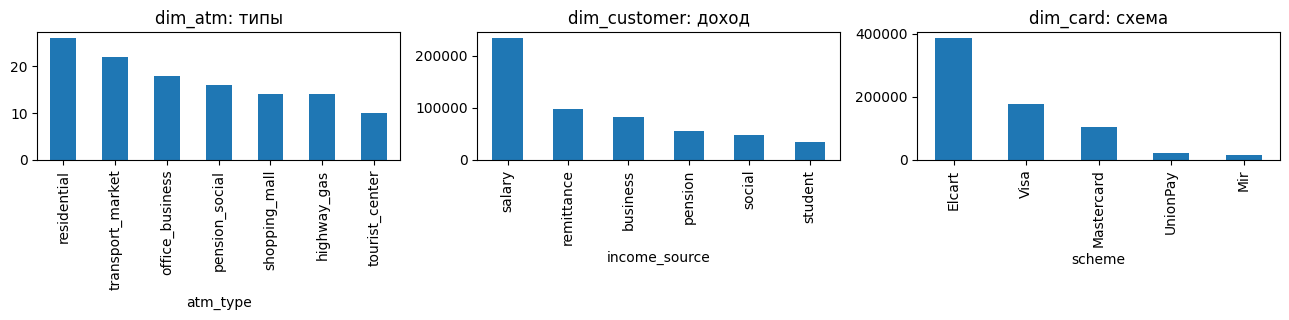

типы ATM: 7 | клиентов: 550,000 | карт: 700,000


In [30]:
fig,ax=plt.subplots(1,3,figsize=(13,3.3))
dim_atm['atm_type'].value_counts().plot.bar(ax=ax[0],title='dim_atm: типы')
cust=pd.read_parquet(DIM/'dim_customer.parquet')
cust['income_source'].value_counts().plot.bar(ax=ax[1],title='dim_customer: доход')
card=pd.read_parquet(DIM/'dim_card.parquet')
card['scheme'].value_counts().plot.bar(ax=ax[2],title='dim_card: схема')
plt.tight_layout(); plt.show()
print('типы ATM:', dim_atm['atm_type'].nunique(), '| клиентов:', f'{len(cust):,}', '| карт:', f'{len(card):,}')
verdicts['4. справочники']='✅ распределения осмысленны'


## 5. dim_calendar — реальные погода и курс

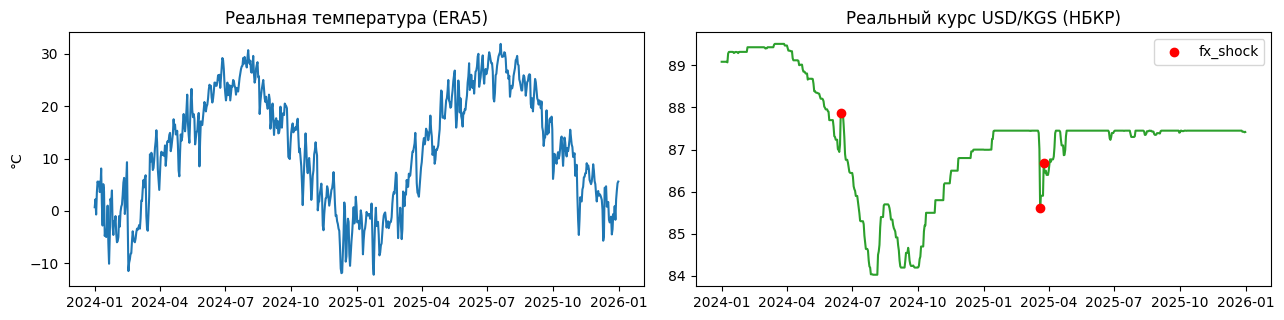

темп: -12..32°C | курс: 84.03..89.51 | fx-шоков: 3


In [31]:
fig,ax=plt.subplots(1,2,figsize=(13,3.3))
ax[0].plot(cal['date'],cal['temp_avg']); ax[0].set_title('Реальная температура (ERA5)'); ax[0].set_ylabel('°C')
ax[1].plot(cal['date'],cal['usd_kgs_rate'],color='tab:green')
sh=cal[cal['fx_shock']]; ax[1].scatter(sh['date'],sh['usd_kgs_rate'],color='red',zorder=3,label='fx_shock')
ax[1].set_title('Реальный курс USD/KGS (НБКР)'); ax[1].legend(); plt.tight_layout(); plt.show()
print(f"темп: {cal['temp_avg'].min():.0f}..{cal['temp_avg'].max():.0f}°C | "
      f"курс: {cal['usd_kgs_rate'].min():.2f}..{cal['usd_kgs_rate'].max():.2f} | fx-шоков: {int(cal['fx_shock'].sum())}")
verdicts['5. календарь']='✅ реальные ряды на месте'


## 6. Транзакции — ключевые распределения

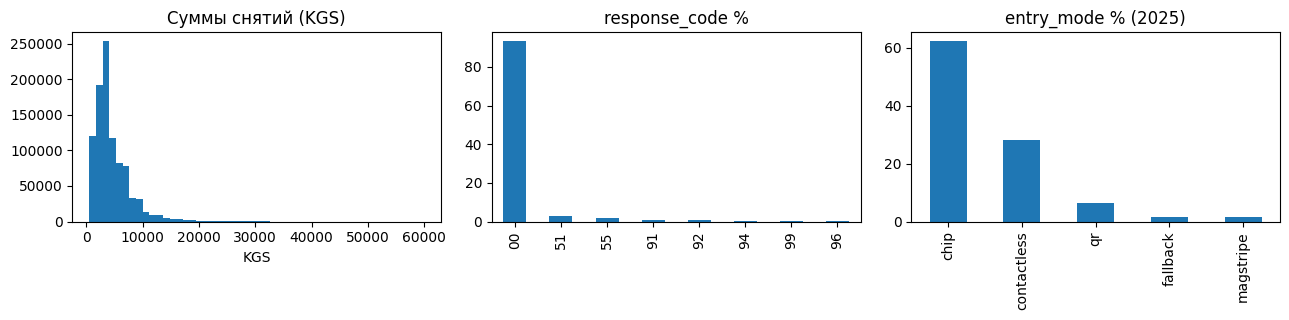

средний чек 4,478 KGS (~$51) | медиана 3,500 | кратно 500: 100% | одобрено 93.2%


In [32]:
fig,ax=plt.subplots(1,3,figsize=(13,3.3))
ax[0].hist(amounts,bins=50); ax[0].set_title('Суммы снятий (KGS)'); ax[0].set_xlabel('KGS')
s=pd.Series(resp).sort_values(ascending=False); (s/s.sum()*100).plot.bar(ax=ax[1],title='response_code %')
ey=pd.Series(entry_year[2025]); (ey/ey.sum()*100).plot.bar(ax=ax[2],title='entry_mode % (2025)')
plt.tight_layout(); plt.show()
appr=(s.get('00',0)/s.sum()*100)
print(f"средний чек {amounts.mean():,.0f} KGS (~${amounts.mean()/87:.0f}) | медиана {np.median(amounts):,.0f} | "
      f"кратно 500: {(amounts%500==0).mean()*100:.0f}% | одобрено {appr:.1f}%")
verdicts['6. транзакции']=f'✅ чек/коды реалистичны (одобрено {appr:.1f}%)'


## 7. Суточные и недельные профили по типам

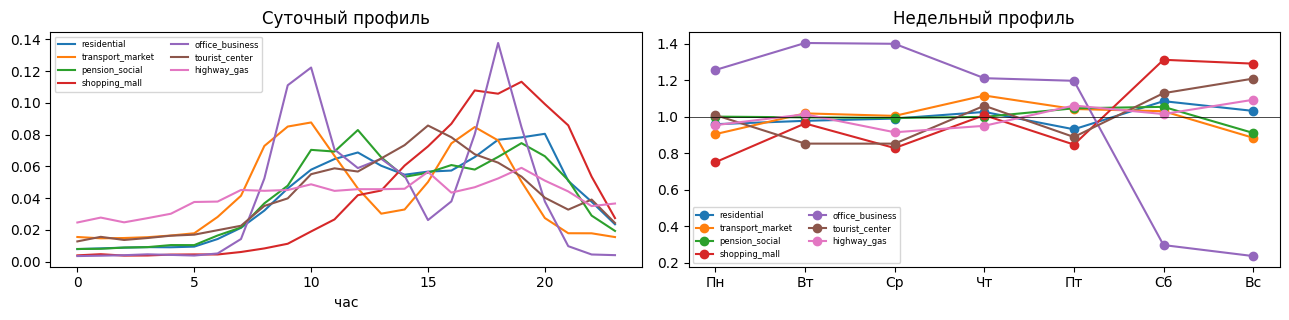

пик часа по типам: {'residential': 20, 'transport_market': 10, 'pension_social': 12, 'shopping_mall': 19, 'office_business': 18, 'tourist_center': 15, 'highway_gas': 19}


In [33]:
fig,ax=plt.subplots(1,2,figsize=(13,3.3))
for t,v in hour_type.items(): ax[0].plot(range(24),v/v.sum(),label=t)
ax[0].set_title('Суточный профиль'); ax[0].set_xlabel('час'); ax[0].legend(fontsize=6,ncol=2)
lbl=['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
for t,v in week_type.items(): ax[1].plot(lbl,v/v.mean(),marker='o',label=t)
ax[1].axhline(1,color='k',lw=.5); ax[1].set_title('Недельный профиль'); ax[1].legend(fontsize=6,ncol=2)
plt.tight_layout(); plt.show()
peaks={t:int((v/v.sum()).argmax()) for t,v in hour_type.items()}
print('пик часа по типам:',peaks)
verdicts['7. профили']=f'✅ {len(set(peaks.values()))} разных суточных пиков'


## 8. Проверка теорий — реальные события двигают данные
Сводим дневной объём с реальными погодой/курсом и календарём.

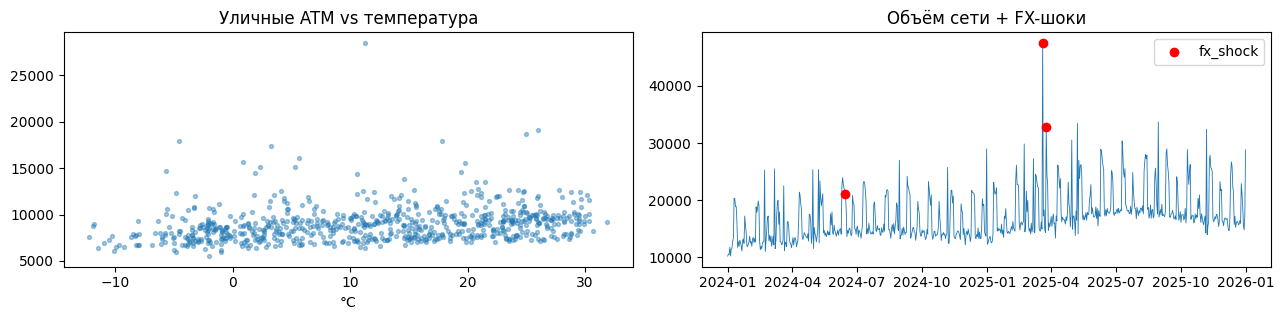

ПОГОДА: уличные мороз/тепло = 0.81x  (ожидаем <1)
FX:     шок/обычный день   = 1.97x  (ожидаем >1)


In [34]:
dd=daily.groupby(['date','street'])[['nn','disp','n99']].sum().reset_index()
dd['date']=pd.to_datetime(dd['date'])
piv=dd.pivot(index='date',columns='street',values='nn').rename(columns={True:'street',False:'indoor'})
piv=piv.join(cal.set_index('date')[['temp_avg','snowfall_mm','fx_shock','is_pre_holiday','is_holiday',
                                     'is_payday','is_pension_day','usd_kgs_rate']])
piv['total']=piv['street']+piv['indoor']; piv['dom']=piv.index.day

fig,ax=plt.subplots(1,2,figsize=(13,3.3))
ax[0].scatter(piv['temp_avg'],piv['street'],s=8,alpha=.4); ax[0].set_title('Уличные ATM vs температура'); ax[0].set_xlabel('°C')
ax[1].plot(piv.index,piv['total'],lw=.6)
sh=piv[piv['fx_shock']]; ax[1].scatter(sh.index,sh['total'],color='red',zorder=3,label='fx_shock')
ax[1].set_title('Объём сети + FX-шоки'); ax[1].legend(); plt.tight_layout(); plt.show()

cold=piv[piv['temp_avg']<-8]['street'].mean(); mild=piv[(piv['temp_avg']>5)&(piv['temp_avg']<25)]['street'].mean()
fxr=piv[piv['fx_shock']]['total'].mean()/piv[~piv['fx_shock']]['total'].mean()
print(f'ПОГОДА: уличные мороз/тепло = {cold/mild:.2f}x  (ожидаем <1)')
print(f'FX:     шок/обычный день   = {fxr:.2f}x  (ожидаем >1)')
verdicts['8. погода+FX']=('✅ реальные события работают' if cold/mild<1 and fxr>1.1 else '⚠️ слабый эффект')


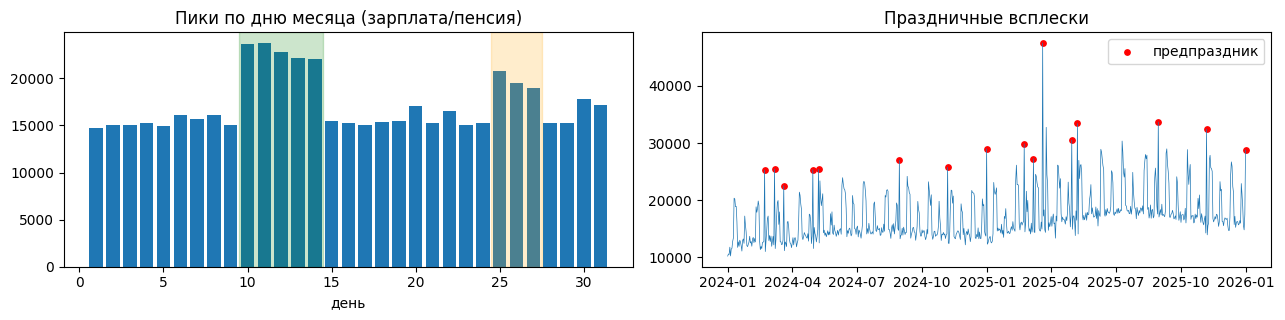

ЗАРПЛАТА: окно 10-14 / фон = 1.42x
ГОД-2:    объём 1.21x, чек 1.08x, digital 2.01x


In [35]:
# зарплата/пенсия по дню месяца, праздники, дрейф год-2
fig,ax=plt.subplots(1,2,figsize=(13,3.3))
bydom=piv.groupby('dom')['total'].mean(); ax[0].bar(bydom.index,bydom.values)
for lo,hi,c in [(10,14,'g'),(25,27,'orange')]: ax[0].axvspan(lo-.5,hi+.5,color=c,alpha=.2)
ax[0].set_title('Пики по дню месяца (зарплата/пенсия)'); ax[0].set_xlabel('день')
ax[1].plot(piv.index,piv['total'],lw=.5)
pre=piv[piv['is_pre_holiday']]; ax[1].scatter(pre.index,pre['total'],color='red',s=15,label='предпраздник')
ax[1].set_title('Праздничные всплески'); ax[1].legend(); plt.tight_layout(); plt.show()

pay=bydom.loc[10:14].mean()/bydom.drop(index=range(10,15)).mean()
r2024=yagg[2024]; r2025=yagg[2025]
tick=r2025[1]/r2025[0]/(r2024[1]/r2024[0]); vol=r2025[0]/r2024[0]
dg=lambda y:(entry_year[y]['contactless']+entry_year[y]['qr'])/sum(entry_year[y].values())
print(f'ЗАРПЛАТА: окно 10-14 / фон = {pay:.2f}x')
print(f'ГОД-2:    объём {vol:.2f}x, чек {tick:.2f}x, digital {dg(2025)/dg(2024):.2f}x')
verdicts['9. календарь+дрейф']=('✅ пики и дрейф видны' if pay>1.1 and tick>1 else '⚠️')


## 9. Аномалии — ground truth и проверка что они реальны

=== labels/ ===
  cash_events      206 строк
  cold_start        14 строк
  drift_spec         1 строк
  events             3 строк
  faults           717 строк
  fraud            256 строк


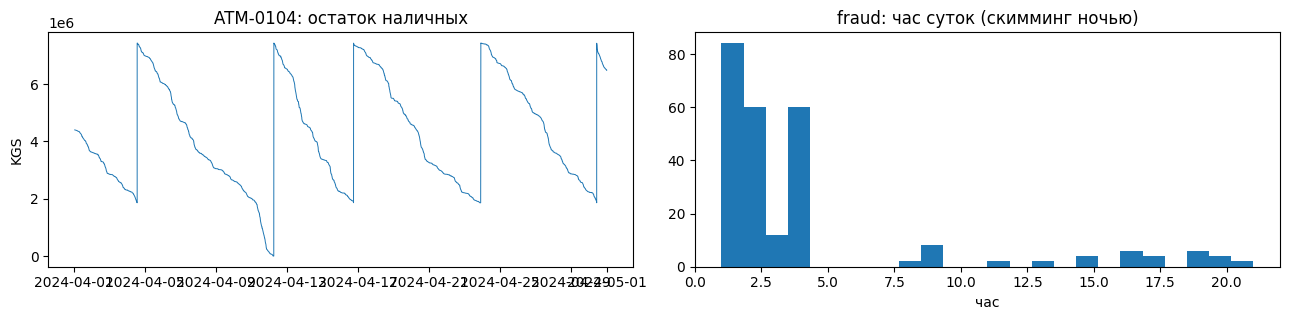

fraud меток 256, найдено в факте 256  |  out_of_cash '99' на ATM-0104: 2


In [36]:
print('=== labels/ ===')
for f in sorted(LAB.glob('*.parquet')):
    print(f'  {f.stem:14s} {len(pd.read_parquet(f)):>5,} строк')

# out_of_cash: показать баланс одного банкомата
ce=pd.read_parquet(LAB/'cash_events.parquet'); r=ce.iloc[0]; a0=r['atm_id']
ym=pd.Timestamp(r['start_ts']).strftime('%Y/%m').split('/')
part=FCT/'fact_transactions'/f'year={ym[0]}'/f'month={ym[1]}'/'part.parquet'
d=pd.read_parquet(part,columns=['atm_id','timestamp','device_cash_level_after','response_code'])
d=d[d['atm_id']==a0].sort_values('timestamp')
fig,ax=plt.subplots(1,2,figsize=(13,3.3))
ax[0].plot(d['timestamp'],d['device_cash_level_after'],lw=.7); ax[0].set_title(f'{a0}: остаток наличных'); ax[0].set_ylabel('KGS')
fr=pd.read_parquet(LAB/'fraud.parquet'); fr['h']=pd.to_datetime(fr['timestamp']).dt.hour
ax[1].hist(fr['h'],bins=24); ax[1].set_title('fraud: час суток (скимминг ночью)'); ax[1].set_xlabel('час')
plt.tight_layout(); plt.show()

fr_ids=set(fr['txn_id'])
found=sum(pd.read_parquet(p,columns=['txn_id'])['txn_id'].isin(fr_ids).sum() for p in parts)
print(f"fraud меток {len(fr)}, найдено в факте {found}  |  out_of_cash '99' на {a0}: {(d['response_code']=='99').sum()}")
verdicts['10. аномалии']=('✅ метки сходятся с фактом' if found==len(fr) else '⚠️ несоответствие')


## 10. Итоговая сводка проверок

In [37]:
print('='*50)
for k,v in verdicts.items(): print(f'{k:22s} {v}')
print('='*50)
ok=sum('✅' in v for v in verdicts.values())
print(f'\nПройдено: {ok}/{len(verdicts)} секций')
print('Датасет готов к работе ✅' if ok==len(verdicts) else 'Есть замечания — см. ⚠️ выше')


1. инвентарь           ✅ 17 таблиц читаются
3. целостность         ✅ все инварианты держатся
4. справочники         ✅ распределения осмысленны
5. календарь           ✅ реальные ряды на месте
6. транзакции          ✅ чек/коды реалистичны (одобрено 93.2%)
7. профили             ✅ 6 разных суточных пиков
8. погода+FX           ✅ реальные события работают
9. календарь+дрейф     ✅ пики и дрейф видны
10. аномалии           ✅ метки сходятся с фактом

Пройдено: 9/9 секций
Датасет готов к работе ✅
